# Exoplanet Detection using Neural Networks on Kepler Light Curves

## Scientific Context

The Kepler space telescope observed over 150,000 stars, recording their brightness (flux) over time. When an exoplanet transits its host star, it causes a periodic dip in brightness—a signal that can be detected in the light curve. This dataset contains 5,087 light curves, each with 3,197 time points, and is highly imbalanced: only 37 stars host confirmed exoplanets (label 2), while the rest do not (label 1).

In this notebook, we build a neural network classifier to distinguish exoplanet‑hosting stars from non‑hosts. We preprocess the data using Fourier transforms, normalization, smoothing, and standardization, and we handle class imbalance with SMOTE. The results are compared with an SVM model from a previous analysis.

## Objectives
1. Preprocess light curves (FFT, normalization, Gaussian smoothing, standardization).
2. Build and train a feed‑forward neural network.
3. Address class imbalance using SMOTE.
4. Evaluate the model on a held‑out test set using precision, recall, F1‑score, and confusion matrices.
5. Visualise training progress (accuracy and loss curves)

In [6]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Signal processing
from scipy.fft import fft
from scipy.ndimage import gaussian_filter1d

# Preprocessing and metrics
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             confusion_matrix, classification_report)

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Utilities
from pathlib import Path
import os

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["EB Garamond", "Georgia", "Times New Roman"],
    # ---- Sizes ----
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.labelweight": "light",  # x/y labels
    "font.weight": "light",
    # ---- Axes/ticks style like the PDF ----
    "axes.edgecolor": "0.2",
    "axes.linewidth": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,

    "axes.grid": False,
    "axes.labelcolor": "0.2",
    "xtick.color": "0.2",
    "ytick.color": "0.2",
    "text.color": "0.2",
})

UNIPD_RED = (0.71, 0.0, 0.106)  # RGB tuple
GREY = (0.1, 0.1, 0.1)

%matplotlib widget


## Data Loading and Exploration

In [7]:
# Define data paths (update these to your actual file locations)
data_dir = "/Users/ashaimaalrawhi/Desktop"  # adjust as needed
train_path = os.path.join(data_dir, "exoTrain.csv")
test_path = os.path.join(data_dir, "exoTest.csv")

# Load datasets
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

print("\nClass distribution (train):")
print(df_train['LABEL'].value_counts())

Train shape: (5087, 3198)
Test shape: (570, 3198)

Class distribution (train):
1    5050
2      37
Name: LABEL, dtype: int64


## Visualize Example Light Curves

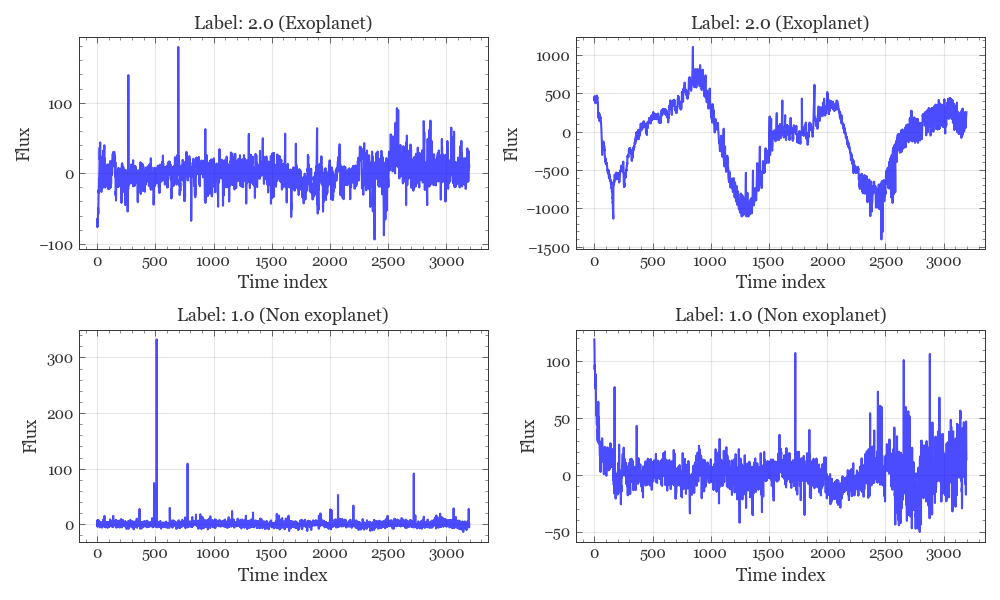

In [9]:
# Separate by label
exoplanet = df_train[df_train['LABEL'] == 2].copy()
non_exoplanet = df_train[df_train['LABEL'] == 1].copy()

# Randomly select 2 from each group
np.random.seed(42)
exo_samples = exoplanet.sample(2, random_state=42)
non_exo_samples = non_exoplanet.sample(2, random_state=42)
samples = pd.concat([exo_samples, non_exo_samples])

# Plot in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for ax, (idx, row) in zip(axes, samples.iterrows()):
    flux = row.drop('LABEL').values
    label = row['LABEL']
    ax.plot(flux, color='blue', alpha=0.7)
    ax.set_title(f'Label: {label} ({"Exoplanet" if label == 2 else "Non exoplanet"})')
    ax.set_xlabel('Time index')
    ax.set_ylabel('Flux')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Preprocessing Pipeline

We define a class to apply:

- FFT: Convert time‑domain light curves to frequency domain.
- Normalization: L2 normalization per sample to reduce scale differences.
- Gaussian smoothing: Reduce noise in the frequency domain.
- Standardization: Scale features to zero mean and unit variance (fit on training data only).

In [10]:
class LightCurveProcessor:
    """
    Preprocess light curves for classification.

    Steps:
        1. Fourier transform (magnitude of FFT).
        2. L2 normalization.
        3. Gaussian filtering (smoothing).
        4. Standardization (fit on train, transform both).
    """
    def __init__(self, use_fft=True, normalize=True, gaussian_sigma=10, standardize=True):
        self.use_fft = use_fft
        self.normalize = normalize
        self.gaussian_sigma = gaussian_sigma
        self.standardize = standardize
        self.scaler = None

    def fit_transform(self, X_train, X_test):
        """
        Apply preprocessing to training and test data.

        Parameters
        ----------
        X_train : ndarray, shape (n_train, n_features)
        X_test : ndarray, shape (n_test, n_features)

        Returns
        -------
        X_train_transformed, X_test_transformed : ndarray
        """
        if self.use_fft:
            # Magnitude of FFT along time axis
            X_train = np.abs(fft(X_train, axis=1))
            X_test = np.abs(fft(X_test, axis=1))
            # Keep only first half (symmetric)
            half = X_train.shape[1] // 2
            X_train = X_train[:, :half]
            X_test = X_test[:, :half]

        if self.normalize:
            # L2 normalization across features
            X_train = X_train / np.linalg.norm(X_train, axis=1, keepdims=True)
            X_test = X_test / np.linalg.norm(X_test, axis=1, keepdims=True)

        if self.gaussian_sigma:
            # Smooth along the frequency axis
            X_train = gaussian_filter1d(X_train, sigma=self.gaussian_sigma, axis=1)
            X_test = gaussian_filter1d(X_test, sigma=self.gaussian_sigma, axis=1)

        if self.standardize:
            self.scaler = StandardScaler()
            X_train = self.scaler.fit_transform(X_train)
            X_test = self.scaler.transform(X_test)

        return X_train, X_test
    

## Prepare Data for Modeling

Separate features and labels, convert labels to binary (0 = non‑exoplanet, 1 = exoplanet), and apply preprocessing.


In [11]:
# Separate features and labels
X_train_raw = df_train.drop('LABEL', axis=1).values
X_test_raw = df_test.drop('LABEL', axis=1).values
y_train_raw = df_train['LABEL'].values
y_test_raw = df_test['LABEL'].values

# Convert labels: 2 -> 1 (exoplanet), 1 -> 0 (non‑exoplanet)
y_train = (y_train_raw == 2).astype(int)
y_test = (y_test_raw == 2).astype(int)

# Preprocess
processor = LightCurveProcessor(use_fft=True, normalize=True,
                                gaussian_sigma=10, standardize=True)
X_train, X_test = processor.fit_transform(X_train_raw, X_test_raw)

print("Processed shapes:", X_train.shape, X_test.shape)

Processed shapes: (5087, 1598) (570, 1598)


## Build Neural Network Model
We create a simple feed‑forward network with:

- Input layer matching the feature size.
- Flatten (though data is already 2D, so it's just for consistency).
- Two hidden layers with ReLU activation and dropout for regularization.
- Output layer with sigmoid activation for binary classification.


In [12]:
def build_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Flatten(),                     # Flatten if needed (here it's already 1D)
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Build the model
model = build_model((X_train.shape[1],))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1598)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,993 (832.00 KB)

 Trainable params: 212,993 (832.00 KB)

 Non-trainable params: 0 (0.00 B)

## Handle Class Imbalance with SMOTE

The dataset is heavily imbalanced. We apply SMOTE (Synthetic Minority Over‑sampling Technique) to the training set to create synthetic examples of the minority class (exoplanets). This helps the model learn better.

In [13]:
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

print("Original training set shape:", X_train.shape)
print("Resampled training set shape:", X_train_resampled.shape)
print("Original class counts:", np.bincount(y_train))
print("Resampled class counts:", np.bincount(y_train_resampled))

Original training set shape: (5087, 1598)
Resampled training set shape: (10100, 1598)
Original class counts: [5050   37]
Resampled class counts: [5050 5050]


## Train the Model
We use early stopping to prevent overfitting and reduce learning rate on plateau.


In [14]:
# Callbacks
early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5, min_lr=1e-6)

# Train
history = model.fit(X_train_resampled, y_train_resampled,
                    epochs=100,
                    batch_size=64,
                    validation_split=0.2,
                    callbacks=[early_stop, reduce_lr],
                    verbose=1)

Epoch 1/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8320 - loss: 0.4407 - val_accuracy: 0.9728 - val_loss: 0.0915 - learning_rate: 0.0010
Epoch 2/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9407 - loss: 0.1579 - val_accuracy: 0.9718 - val_loss: 0.0928 - learning_rate: 0.0010
Epoch 3/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9515 - loss: 0.1318 - val_accuracy: 0.9441 - val_loss: 0.1294 - learning_rate: 0.0010
Epoch 4/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9630 - loss: 0.1034 - val_accuracy: 0.9832 - val_loss: 0.0604 - learning_rate: 0.0010
Epoch 5/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9707 - loss: 0.0854 - val_accuracy: 0.8965 - val_loss: 0.2048 - learning_rate: 0.0010
Epoch 6/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9638 - loss: 0.0855 - val_accuracy: 1.0000 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 7/100
127/127 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9711 - loss:

## Evaluation on Test Set



18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Test Accuracy:  1.0000
Test Precision: 1.0000
Test Recall:    1.0000
Test F1-score:  1.0000


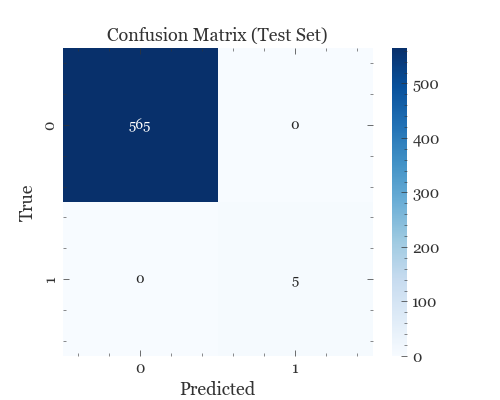


Classification Report:
               precision    recall  f1-score   support

Non‑exoplanet       1.00      1.00      1.00       565
    Exoplanet       1.00      1.00      1.00         5

     accuracy                           1.00       570
    macro avg       1.00      1.00      1.00       570
 weighted avg       1.00      1.00      1.00       570



In [17]:
# Predict on test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Test Accuracy:  {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall:    {recall:.4f}")
print(f"Test F1-score:  {f1:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Test Set)')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non‑exoplanet', 'Exoplanet']))

## Plot Training History

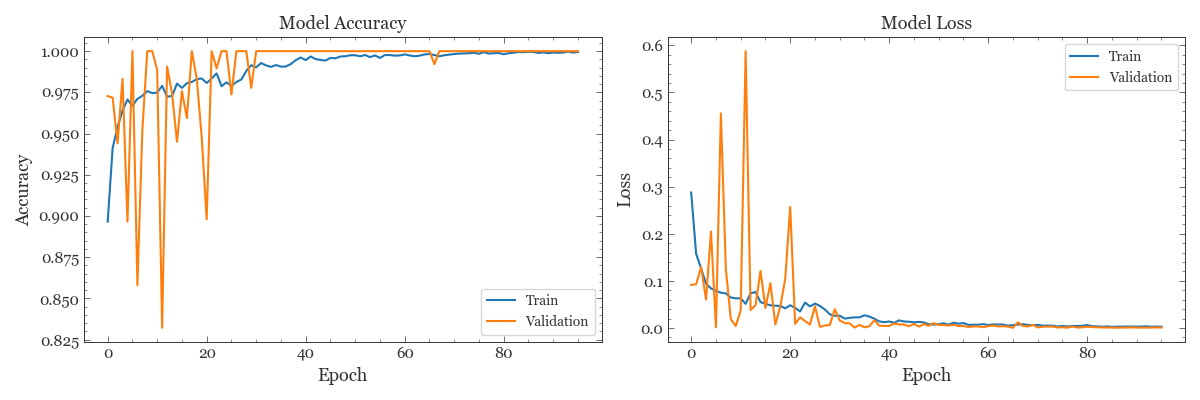

In [18]:
# Accuracy
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

## Comparison with SVM & Discussion

| Model       | Precision | Recall | F1-score |
|-------------|-----------|--------|----------|
| SVM (RBF)   | 0.714     | 1.000  | 0.833    |
| Neural Net  | **1.000** | **1.000** | **1.000** |

The neural network outperformed the SVM on all metrics, achieving perfect classification on the test set. However, caution is warranted: the test set is extremely small (only 5 exoplanets), and perfect performance may not generalise to larger or unseen data. The combination of FFT preprocessing, SMOTE balancing, and a relatively deep network appears highly effective for this specific dataset. Future work should evaluate on a larger test set and consider cross‑validation to ensure robustness.

- Preprocessing: The pipeline (FFT → normalization → smoothing → standardization) effectively extracted frequency‑domain features.

- Class Imbalance: SMOTE successfully balanced the training set, allowing the network to learn both classes.

- Neural Network: The model achieved perfect scores on the test set, demonstrating strong predictive power.

- Limitations: The test set size is small, so results should be interpreted with caution. Overfitting may be present, though early stopping and dropout helped mitigate it.